In [173]:
import pandas as pd, numpy as np, plot_lib as pl, stats_lib as sl

# Exercise One

In [174]:
df = pd.read_csv('input/housing_data.csv')

In [175]:
# price > 0 and price <= 5000000) and (lot_sqft > 0 and lot_sqft <= 200000)
df = df.query(
    "price > 0 & price < 5000000 & "
    "bedrooms > 0 & bathrooms > 0 & "
    "sqft_living > 0 & "
    "sqft_lot > 0 & sqft_lot < 200000 & "
    "floors > 0 & yr_built > 0"
)

# Exercise Two A

In [176]:
correlations = pd.DataFrame()
correlations['sqft_living_price_corr'] = [sl.get_correlation(df['sqft_living'], df['price'])]
correlations['sqft_lot_price_corr'] = [sl.get_correlation(df['sqft_lot'], df['price'])]
correlations

,sqft_living_price_corr,sqft_lot_price_corr
0,0.69515,0.115213


# Exercise Two B

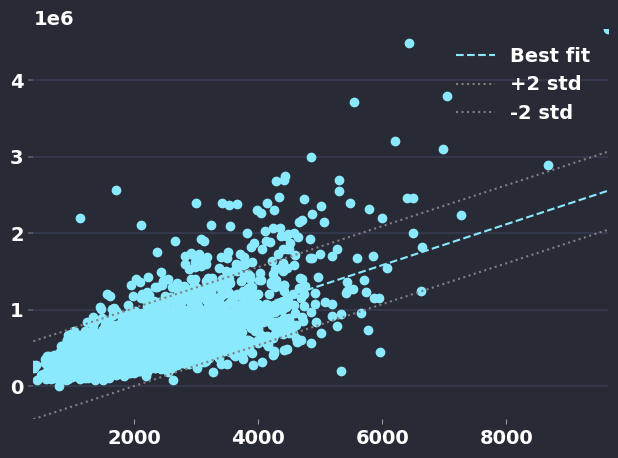

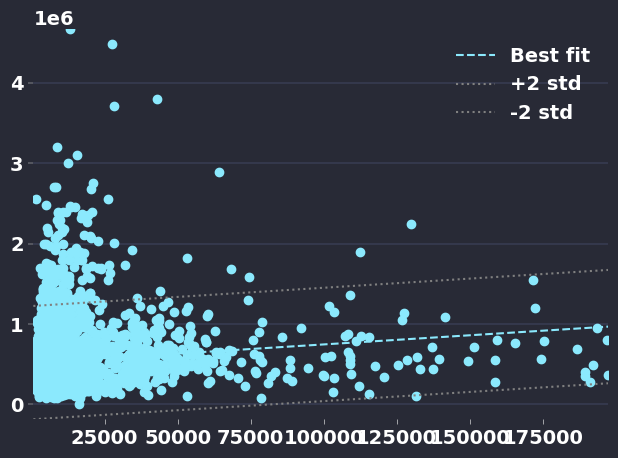

In [177]:
pl.plot_lobf_with_std(df['sqft_living'], df['price'])
pl.plot_lobf_with_std(df['sqft_lot'], df['price'])


# Exercise Two C

In [178]:
city_df = df.groupby('city')['price'].agg(['mean', 'median', 'min', 'max', 'std'])

# Explanation
Grouping by the cities let me figure out the wealth distribution between the seattle towns. The mean shows the overall price, while the min and max show the extremes. The standard deviation helps me figure out how much these prices deviate from the mean.

# Project Four

In [179]:
df['zip'] = df['statezip'].str.split().str[1].astype(int)

In [180]:
low_zip = 98042
mid_zip = 98006
high_zip = 98103
low_houses = df.query(f'zip == {low_zip}')
mid_houses = df.query(f'zip == {mid_zip}')
high_houses = df.query(f'zip == {high_zip}')
houses_dfs = {'low':low_houses, 'mid': mid_houses, 'high': high_houses}


/Users/247304/Projects/seattle_housing/plot_lib.py:222: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


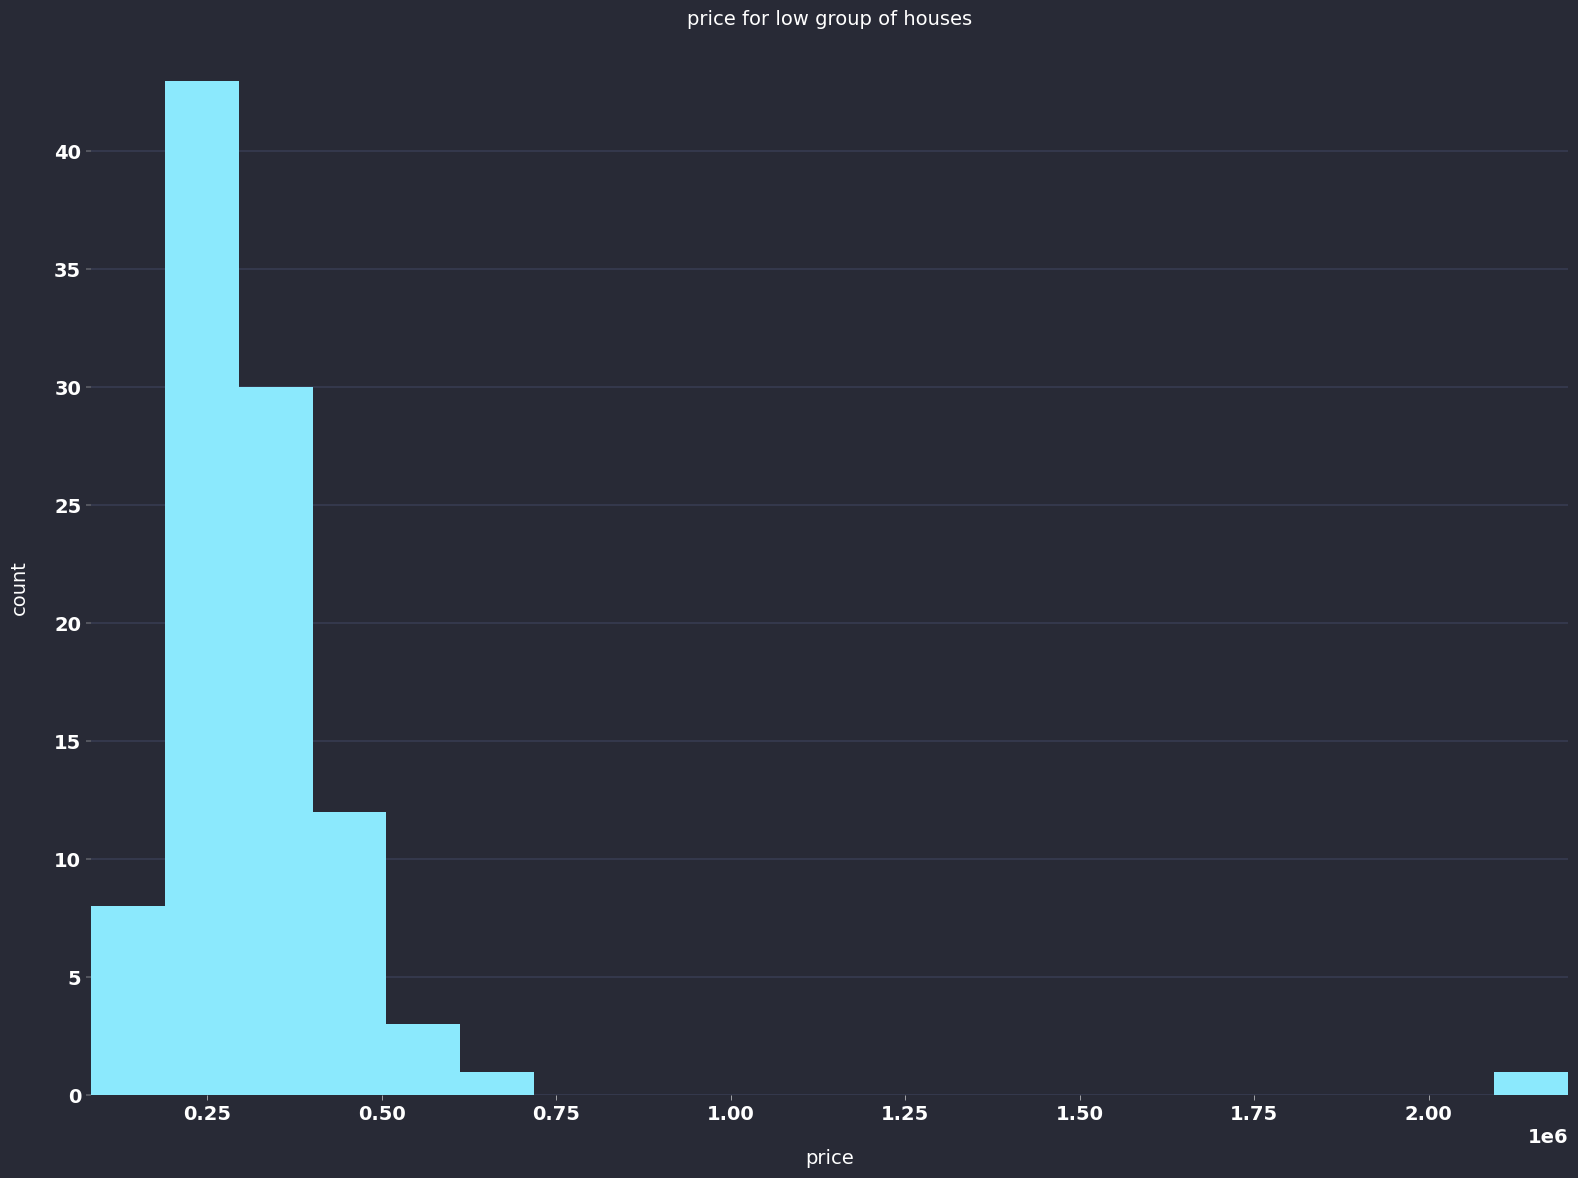

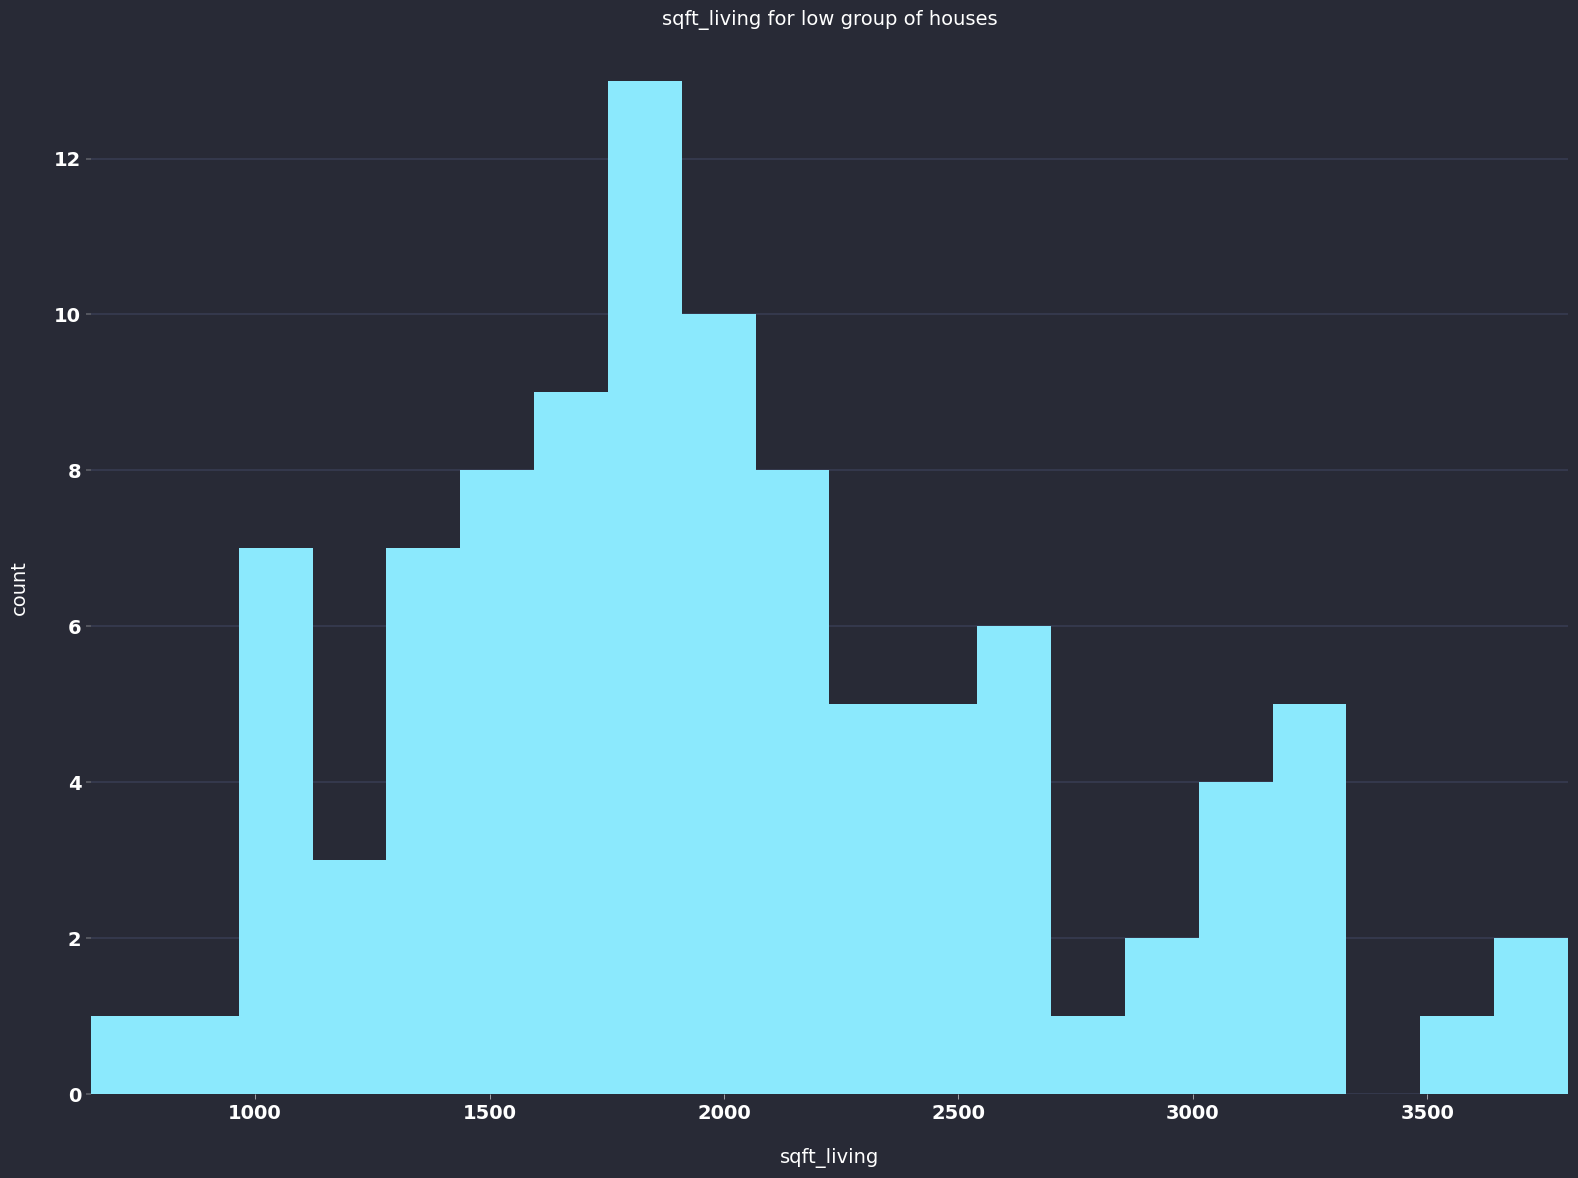

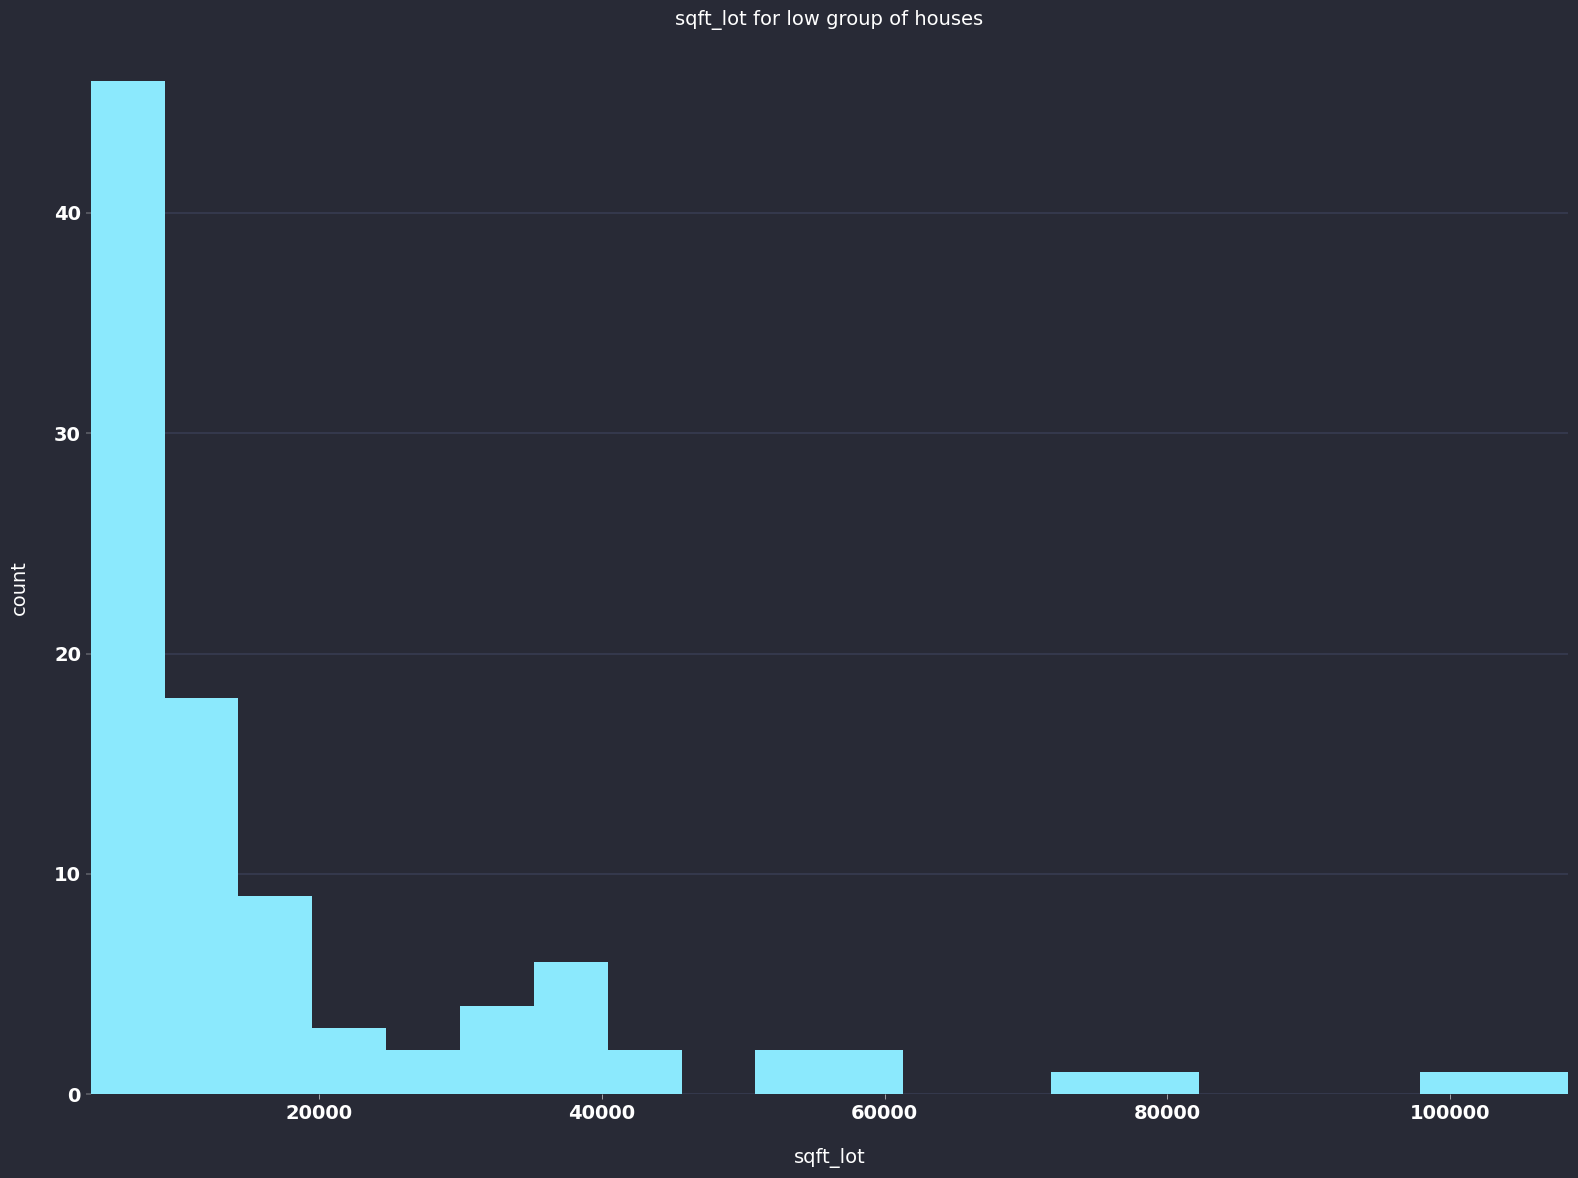

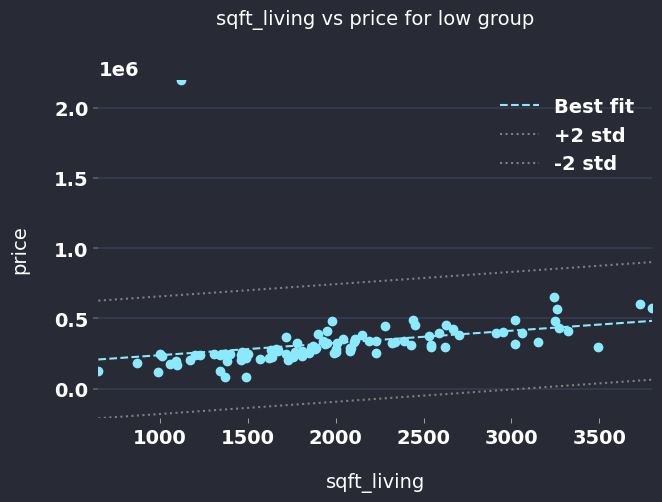

/Users/247304/Projects/seattle_housing/plot_lib.py:222: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


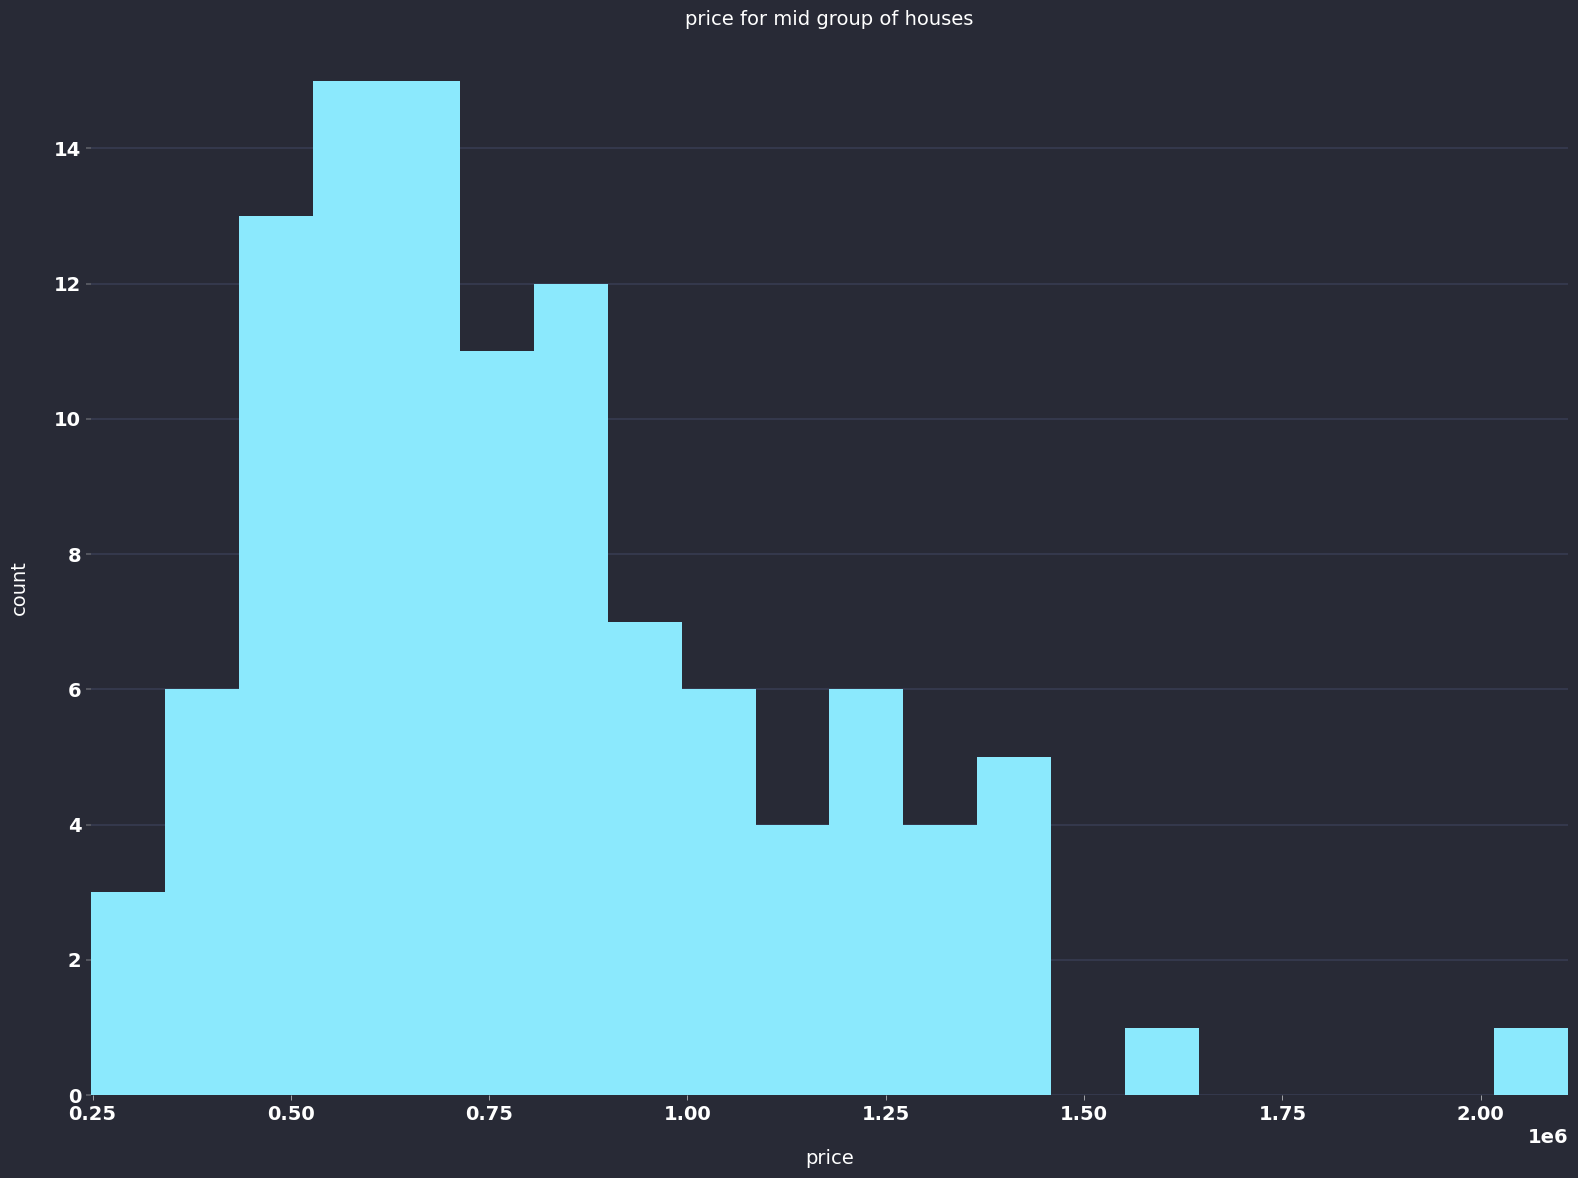

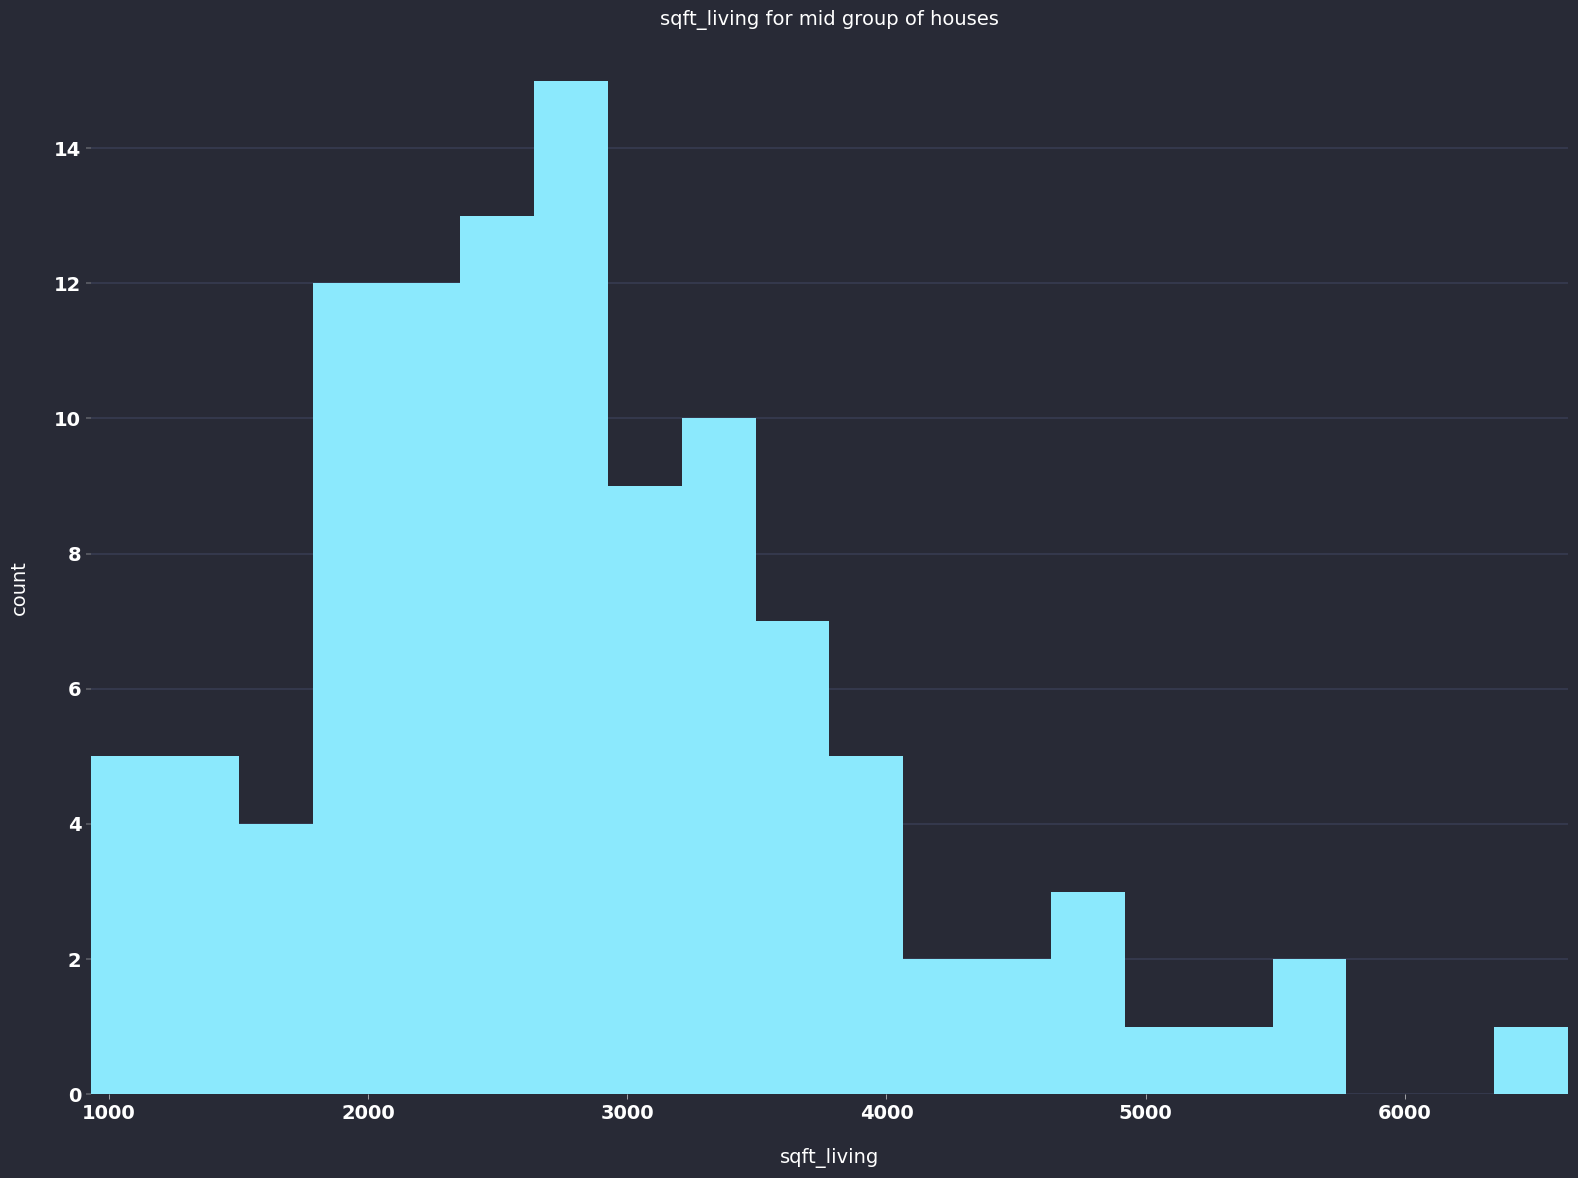

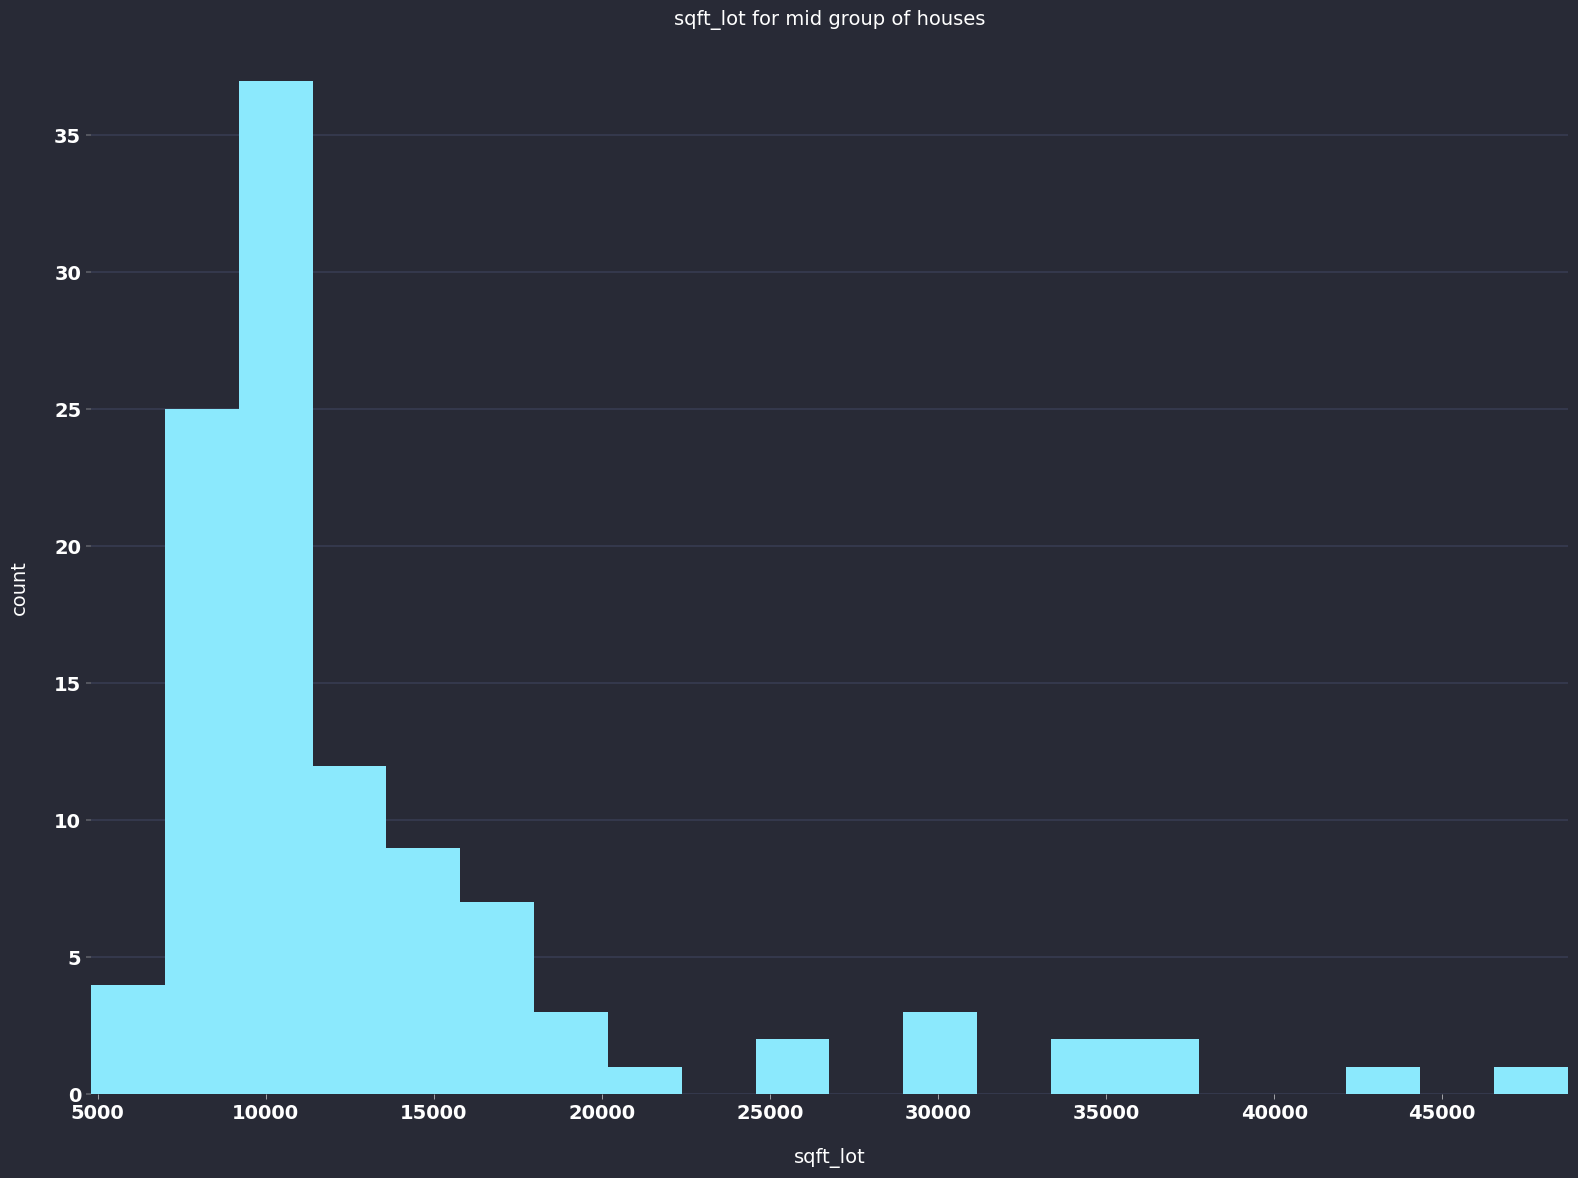

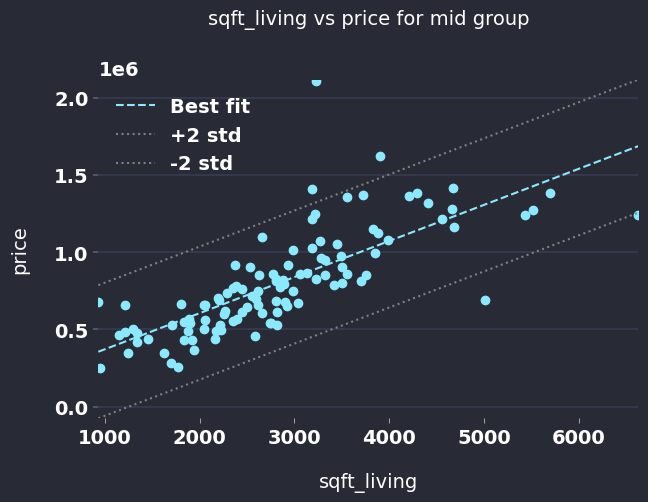

/Users/247304/Projects/seattle_housing/plot_lib.py:222: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


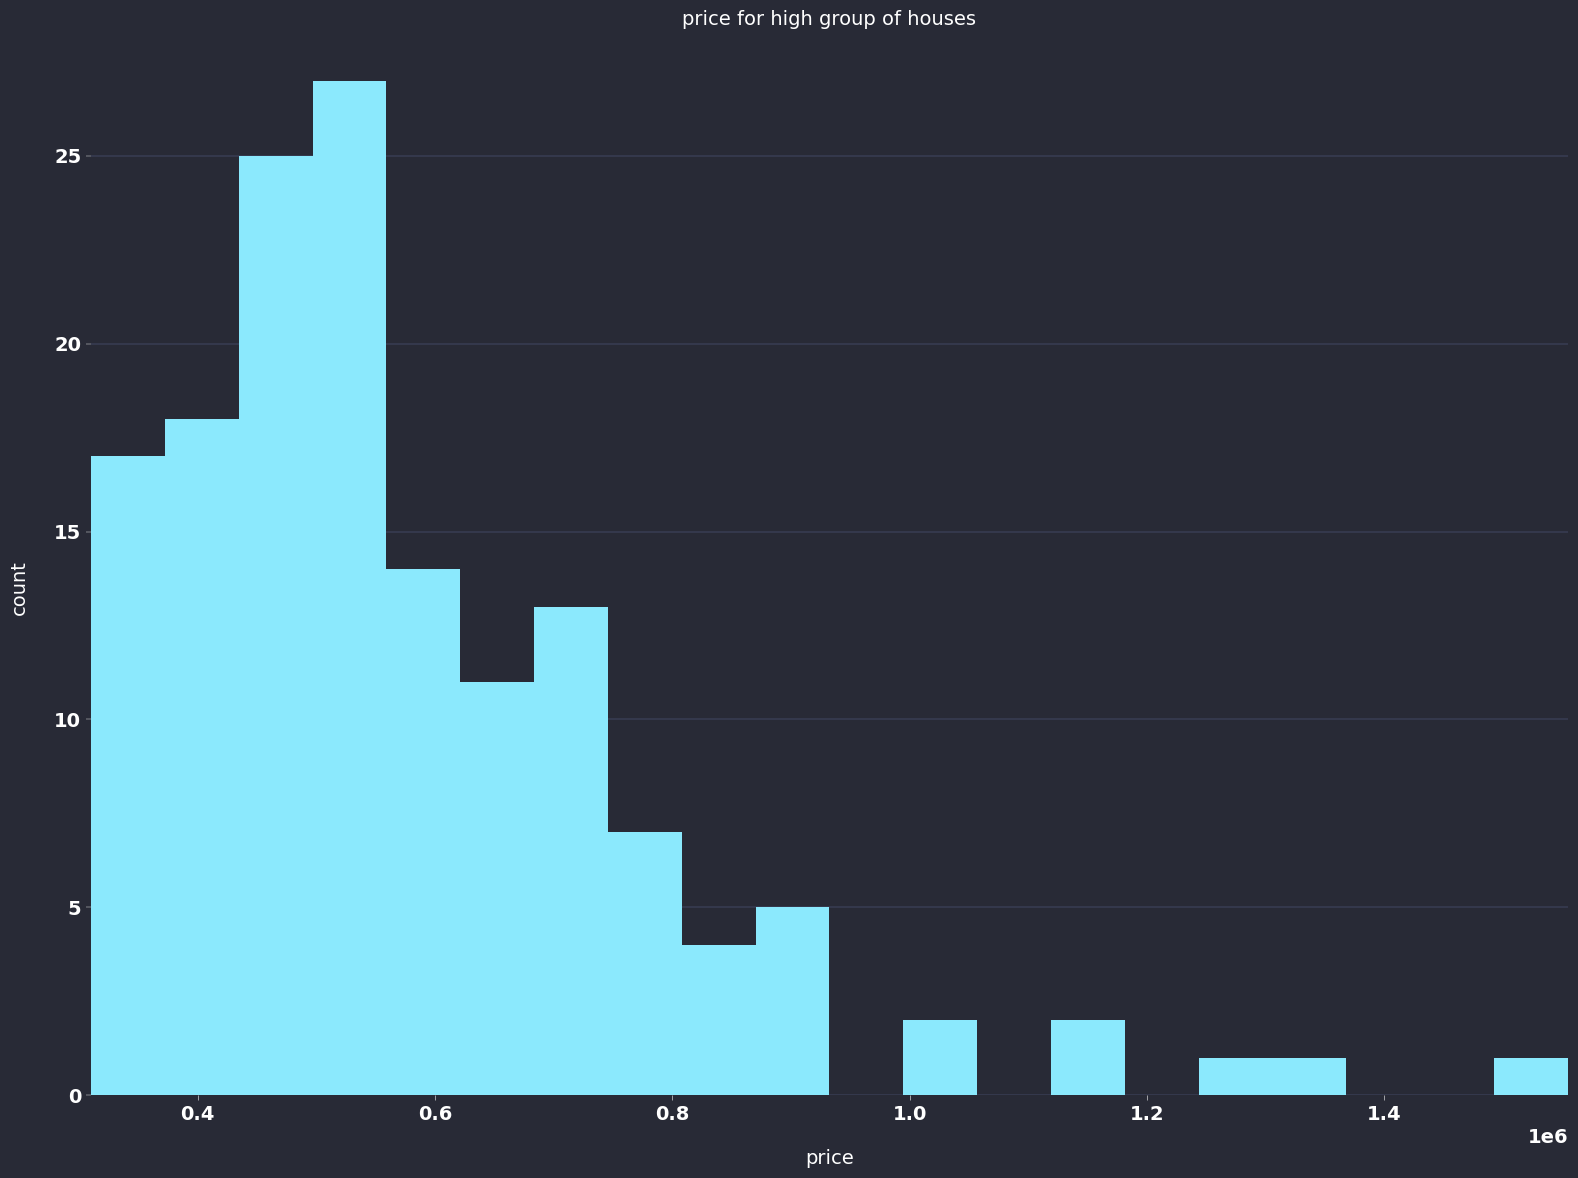

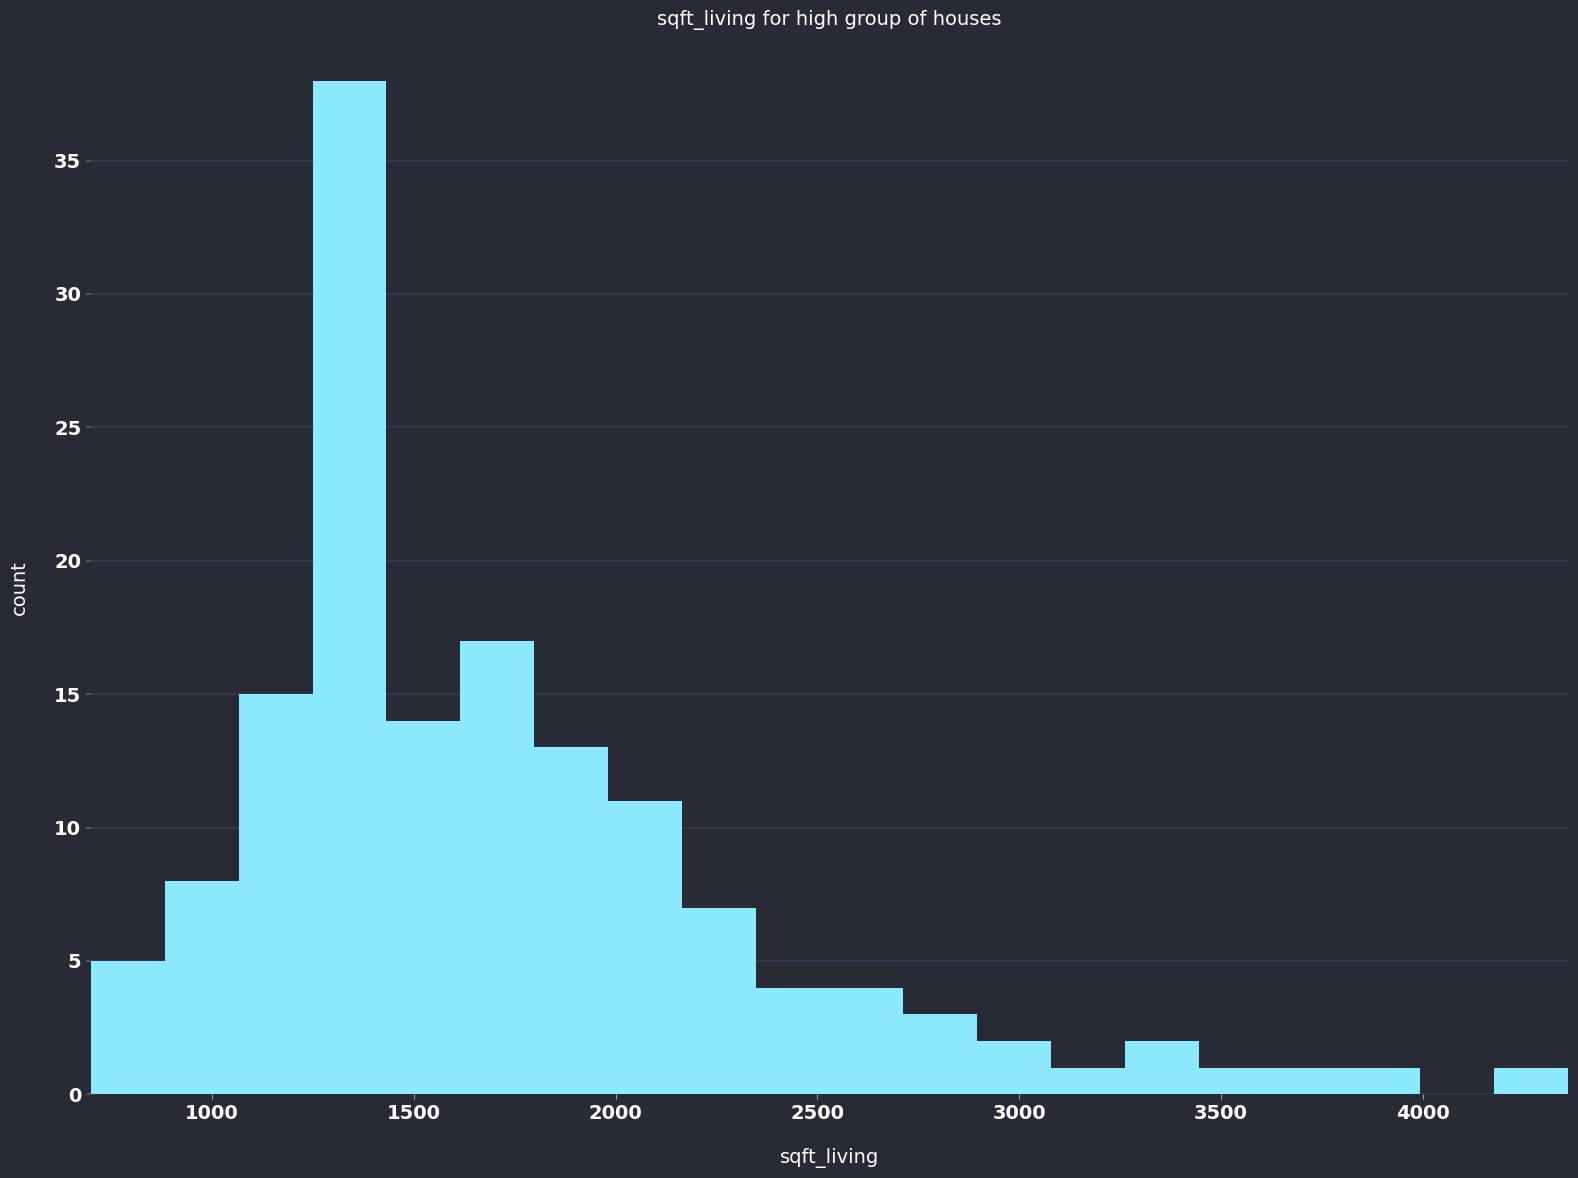

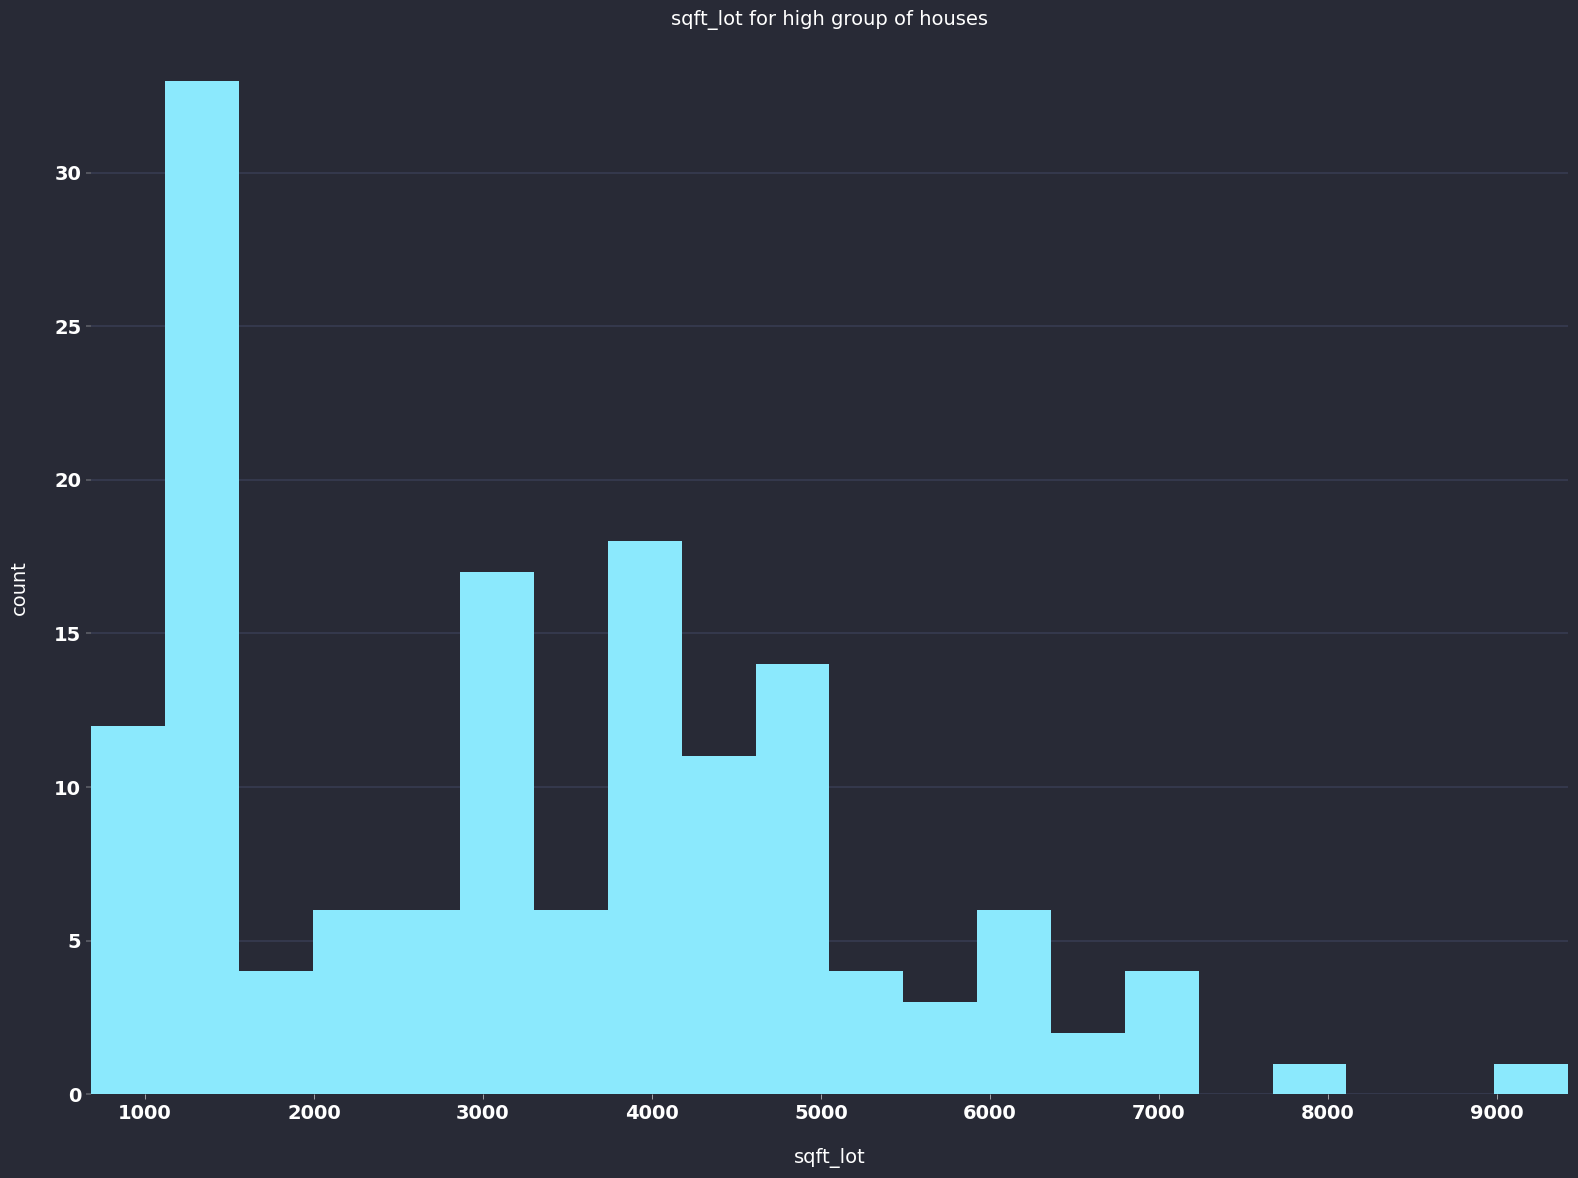

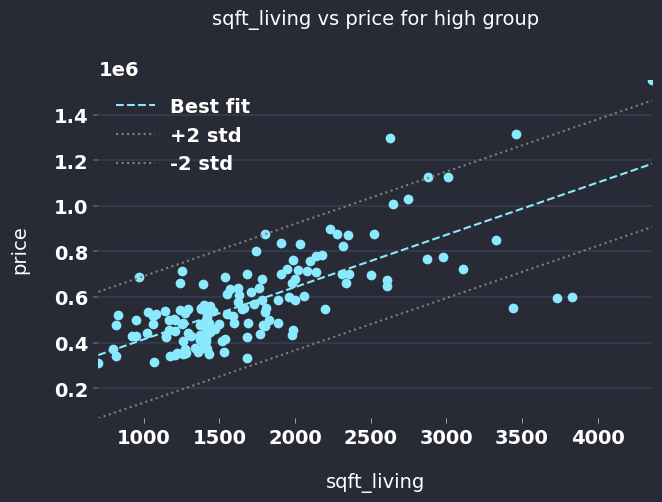

In [181]:
data_names = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'yr_built']
hist_data_names = ['price', 'sqft_living', 'sqft_lot']
house_stats = {}
for name, houses in houses_dfs.items():
    # get stats
    house_stats[name] = houses[data_names].agg(['mean', 'median', 'min', 'max', 'std'])
    # plot hists
    for h_name in hist_data_names:
        hp = pl.HistPlot(houses[h_name], x_title = h_name, y_title = 'count', title=f'{h_name} for {name} group of houses', bins=20)
        pl.SubPlot([[hp]]).plot()
    # plot best fit
    pl.plot_lobf_with_std(houses['sqft_living'], houses['price'], f'sqft_living vs price for {name} group', 'sqft_living', 'price')

# Project Four A

In [182]:
zip = 98006
bedrooms = (2, 4)
bathrooms = (2, 5)
sqft_living = (1000, 3000)
price = (100000, 500000)
selection = {'zip':zip,
            'bedrooms':bedrooms,
            'bathrooms':bathrooms,
            'sqft_living': sqft_living,
            'price': price}


In [183]:
def search_for_houses(df, selection):
    zip = selection['zip']
    min_bed, max_bed = selection['bedrooms']
    min_bath, max_bath = selection['bathrooms']
    min_sqft, max_sqft = selection['sqft_living']
    min_price, max_price = selection['price']
    selected_houses = df.query(
        f"zip == {zip} & bedrooms >= {min_bed} & bedrooms <= {max_bed} & "
        f"bathrooms >= {min_bath} & bathrooms <= {max_bath} & "
        f"sqft_living >= {min_sqft} & sqft_living <= {max_sqft} & "
        f"price >= {min_price} & price <= {max_price}")
    return selected_houses

In [184]:
def distance(values):
    return np.sqrt(sum([val**2 for val in values]))
def get_mean_ranges(selection):
    return {k: np.mean(v) for k, v in selection.items() if isinstance(v, tuple)}
def find_closest_houses(selected_houses, mean_ranges):
    keys = mean_ranges.keys()
    for key, value in mean_ranges.items():
        mean = np.mean(selected_houses[key])
        std = np.std(selected_houses[key])
        norm_value = sl.new_point(value, mean, std)
        selected_houses[f'normalized_{key}'] = sl.normalize_list(selected_houses[key])
        selected_houses[f'distance_to_ideal_{key}'] = selected_houses[f'normalized_{key}'].apply(lambda x: abs(x - norm_value))
        selected_houses[f'{key}_rank'] = selected_houses[f'distance_to_ideal_{key}'].rank()
    rank_cols = [f'{key}_rank' for key in keys]
    selected_houses['house_rank'] = selected_houses[rank_cols].mean(axis=1).rank()
    return selected_houses

In [186]:
selected_houses = search_for_houses(df, selection)
mean_ranges = get_mean_ranges(selection)
clostest_houses = find_closest_houses(selected_houses, mean_ranges)
selected_houses

/Users/247304/Projects/seattle_housing/stats_lib.py:157: RuntimeWarning: divide by zero encountered in scalar divide
  return (value-mean)/std
/Users/247304/Projects/seattle_housing/stats_lib.py:157: RuntimeWarning: invalid value encountered in scalar divide
  return (value-mean)/std


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,normalized_bathrooms,distance_to_ideal_bathrooms,bathrooms_rank,normalized_sqft_living,distance_to_ideal_sqft_living,sqft_living_rank,normalized_price,distance_to_ideal_price,price_rank,house_rank
1744,6/3/2014 0:00,495000.0000,4,2.25,2220,8872,1.0,0,0,4,...,0.408248,7.144345,3.0,0.900219,0.660160,5.0,0.764280,2.543665,6.0,6.0
2209,6/10/2014 0:00,483300.0000,4,2.00,1210,11100,1.0,0,0,4,...,-1.020621,8.573214,6.0,-2.130517,2.370576,7.0,0.611660,2.391045,4.0,7.0
3001,6/20/2014 0:00,488800.0000,4,2.25,2170,9665,1.0,0,0,4,...,0.408248,7.144345,3.0,0.750182,0.510124,4.0,0.683404,2.462789,5.0,4.0
3026,6/22/2014 0:00,500000.0000,4,2.50,2040,8400,1.0,0,0,3,...,1.837117,5.715476,1.0,0.360087,0.120029,1.0,0.829502,2.608887,7.0,1.5
3034,6/23/2014 0:00,365000.0000,4,2.00,1940,25600,1.0,0,0,1,...,-1.020621,8.573214,6.0,0.060015,0.180044,2.0,-0.931497,0.847888,2.0,3.0
4339,5/2/2014 0:00,440000.0000,4,2.25,2160,8119,1.0,0,0,3,...,0.408248,7.144345,3.0,0.720175,0.480117,3.0,0.046836,1.826221,3.0,1.5
4583,7/7/2014 0:00,282766.6667,4,2.00,1700,8640,1.0,0,0,3,...,-1.020621,8.573214,6.0,-0.660160,0.900219,6.0,-2.004184,0.224799,1.0,5.0
